## Ambiente e bibliotecas

Este notebook foi desenvolvido em Python 3.12.13. As bibliotecas utilizadas e
suas versões estão listadas no arquivo `requirements.txt`, incluído junto com
esta entrega.

#  1) Subida e análise das bases

In [ ]:
import numpy as np

import pandas as pd

cad = pd.read_csv('base_cadastral.csv', sep=';')
info = pd.read_csv('base_info.csv', sep=';')
dev = pd.read_csv('base_pagamentos_desenvolvimento.csv', sep=';')
test = pd.read_csv('base_pagamentos_teste.csv', sep=';')

cad.head(10)
cad.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1315 entries, 0 to 1314
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID_CLIENTE           1315 non-null   int64 
 1   DATA_CADASTRO        1315 non-null   object
 2   DDD                  1078 non-null   object
 3   FLAG_PF              66 non-null     object
 4   SEGMENTO_INDUSTRIAL  1232 non-null   object
 5   DOMINIO_EMAIL        1285 non-null   object
 6   PORTE                1274 non-null   object
 7   CEP_2_DIG            1315 non-null   object
dtypes: int64(1), object(7)
memory usage: 82.3+ KB


In [ ]:
info.head(10)
info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24401 entries, 0 to 24400
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID_CLIENTE          24401 non-null  int64  
 1   SAFRA_REF           24401 non-null  object 
 2   RENDA_MES_ANTERIOR  23684 non-null  float64
 3   NO_FUNCIONARIOS     23149 non-null  float64
dtypes: float64(2), int64(1), object(1)
memory usage: 762.7+ KB


In [ ]:
dev.head(10)
dev.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77414 entries, 0 to 77413
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID_CLIENTE              77414 non-null  int64  
 1   SAFRA_REF               77414 non-null  object 
 2   DATA_EMISSAO_DOCUMENTO  77414 non-null  object 
 3   DATA_PAGAMENTO          77414 non-null  object 
 4   DATA_VENCIMENTO         77414 non-null  object 
 5   VALOR_A_PAGAR           76244 non-null  float64
 6   TAXA                    77414 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 4.1+ MB


In [ ]:
test.head(10)
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12275 entries, 0 to 12274
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID_CLIENTE              12275 non-null  int64  
 1   SAFRA_REF               12275 non-null  object 
 2   DATA_EMISSAO_DOCUMENTO  12275 non-null  object 
 3   DATA_VENCIMENTO         12275 non-null  object 
 4   VALOR_A_PAGAR           12144 non-null  float64
 5   TAXA                    12275 non-null  float64
dtypes: float64(2), int64(1), object(3)
memory usage: 575.5+ KB


#  1.1) Proporção de valores nulos em cada base

In [ ]:
nulos = cad.isnull().sum()
nulos_pct = (nulos / len(cad) * 100).round(1)
nulos_pct

,0
ID_CLIENTE,0.0
DATA_CADASTRO,0.0
DDD,18.0
FLAG_PF,95.0
SEGMENTO_INDUSTRIAL,6.3
DOMINIO_EMAIL,2.3
PORTE,3.1
CEP_2_DIG,0.0


In [ ]:
nulos = info.isnull().sum()
nulos_pct = (nulos / len(info) * 100).round(1)
nulos_pct

,0
ID_CLIENTE,0.0
SAFRA_REF,0.0
RENDA_MES_ANTERIOR,2.9
NO_FUNCIONARIOS,5.1


In [ ]:
# Todas os pagamentos foram realizados, mesmo se tiveram atrasos

# Questão: E se tivesse inadiplêcia sem nenhum pagamento efetuado (mesmo que atrasado)?

nulos = dev.isnull().sum()
nulos_pct = (nulos / len(dev) * 100).round(1)
nulos_pct

,0
ID_CLIENTE,0.0
SAFRA_REF,0.0
DATA_EMISSAO_DOCUMENTO,0.0
DATA_PAGAMENTO,0.0
DATA_VENCIMENTO,0.0
VALOR_A_PAGAR,1.5
TAXA,0.0


In [ ]:
nulos = test.isnull().sum()
nulos_pct = (nulos / len(test) * 100).round(1)
nulos_pct

,0
ID_CLIENTE,0.0
SAFRA_REF,0.0
DATA_EMISSAO_DOCUMENTO,0.0
DATA_VENCIMENTO,0.0
VALOR_A_PAGAR,1.1
TAXA,0.0


# 1.2) Verificação de **duplicadas**

In [ ]:
print("Duplicados em base_cadastral (por ID_CLIENTE):", cad.duplicated(subset=['ID_CLIENTE']).sum())
print("Duplicados em base_info (por ID_CLIENTE + SAFRA_REF):", info.duplicated(subset=['ID_CLIENTE', 'SAFRA_REF']).sum())
print("Duplicados em base_pagamentos_desenvolvimento (por ID_CLIENTE + SAFRA_REF):", dev.duplicated(subset=['ID_CLIENTE', 'SAFRA_REF']).sum())
print("Duplicados em base_pagamentos_teste (por ID_CLIENTE + SAFRA_REF):", test.duplicated(subset=['ID_CLIENTE', 'SAFRA_REF']).sum())

Duplicados em base_cadastral (por ID_CLIENTE): 0
Duplicados em base_info (por ID_CLIENTE + SAFRA_REF): 0
Duplicados em base_pagamentos_desenvolvimento (por ID_CLIENTE + SAFRA_REF): 56293
Duplicados em base_pagamentos_teste (por ID_CLIENTE + SAFRA_REF): 8836


In [ ]:
print("Combinações únicas de cliente+mês em dev:", dev.shape[0] - 56293)
print("Combinações únicas de cliente+mês em test:", test.shape[0] - 8836)

Combinações únicas de cliente+mês em dev: 21121
Combinações únicas de cliente+mês em test: 3439


# **2.0)  Construção da Target**

# **2.1) Conversão das datas**

In [ ]:
# Apenas dev é preciso para criar o target

dev['DATA_EMISSAO_DOCUMENTO'] = pd.to_datetime(dev['DATA_EMISSAO_DOCUMENTO'])
dev['DATA_PAGAMENTO'] = pd.to_datetime(dev['DATA_PAGAMENTO'])
dev['DATA_VENCIMENTO'] = pd.to_datetime(dev['DATA_VENCIMENTO'])

dev.dtypes

,0
ID_CLIENTE,int64
SAFRA_REF,object
DATA_EMISSAO_DOCUMENTO,datetime64[ns]
DATA_PAGAMENTO,datetime64[ns]
DATA_VENCIMENTO,datetime64[ns]
VALOR_A_PAGAR,float64
TAXA,float64


# **2.2) Cálculo do atraso**

In [ ]:
dev['ATRASO_DIAS'] = (dev['DATA_PAGAMENTO'] - dev['DATA_VENCIMENTO']).dt.days

dev['ATRASO_DIAS'].describe()

# min com antecipação de 7 anos???

,ATRASO_DIAS
count,77414.000000
mean,-0.171429
std,25.229477
min,-2661.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,869.000000


In [ ]:
# verificação dos pagamentos mais antecipados (suspeitos -> possível erro)

dev.sort_values('ATRASO_DIAS').head(5)

,ID_CLIENTE,SAFRA_REF,DATA_EMISSAO_DOCUMENTO,DATA_PAGAMENTO,DATA_VENCIMENTO,VALOR_A_PAGAR,TAXA,ATRASO_DIAS
33271,3829967475074118757,2019-12,2019-12-01,2019-12-17,2027-03-31,194329.49,5.99,-2661
34543,1097345589386012260,2019-11,2019-11-20,2019-12-27,2025-08-27,659850.00,5.99,-2070
5166,8724731934863284019,2018-11,2018-11-04,2018-11-19,2024-01-28,150000.00,6.99,-1896
5167,8724731934863284019,2018-11,2018-11-04,2018-11-19,2024-01-28,40000.00,6.99,-1896
70245,8535586342375301953,2021-03,2021-03-23,2021-04-07,2024-10-31,180000.00,11.99,-1303


In [ ]:
# Verificação do prazo de pagamento (por volta de 23 dias - ok)

# O prazo de 2677 dias é um outlier

dev['PRAZO_DIAS'] = (dev['DATA_VENCIMENTO'] - dev['DATA_EMISSAO_DOCUMENTO']).dt.days
dev['PRAZO_DIAS'].describe()

,PRAZO_DIAS
count,77414.000000
mean,23.320575
std,26.137018
min,-420.000000
25%,16.000000
50%,18.000000
75%,24.000000
max,2677.000000


In [ ]:
# verificação de onde está o erro por percentil

dev['PRAZO_DIAS'].quantile([0.90, 0.95, 0.99, 0.995, 0.999, 1.0])

,PRAZO_DIAS
0.900,35.0
0.950,45.0
0.990,93.0
0.995,124.0
0.999,199.0
1.000,2677.0


In [ ]:
# casos de vencimento antes da emissão (prazo negativo) ?

(dev['PRAZO_DIAS'] < 0).sum()

np.int64(27)

In [ ]:
# linhas com prazos acima de 200 dias - é um grupo pequeno

(dev['PRAZO_DIAS'] > 200).sum()

np.int64(66)

In [ ]:
# prazos "negativos" ou acima de 200 dias

dev[(dev['PRAZO_DIAS'] < 0) | (dev['PRAZO_DIAS'] > 200)].shape[0]

93

**2.2.1) Decisão de excluir todas as linhas fora do intervalo de 200 dias (93 linhas de 77414)**

In [ ]:
linhas_antes = dev.shape[0]

dev = dev[(dev['PRAZO_DIAS'] >= 0) & (dev['PRAZO_DIAS'] <= 200)].copy()

linhas_depois = dev.shape[0]
print("Linhas antes:", linhas_antes)
print("Linhas depois:", linhas_depois)
print("Linhas removidas:", linhas_antes - linhas_depois)

Linhas antes: 77414
Linhas depois: 77321
Linhas removidas: 93


In [ ]:
# varificação dos inadiplentes

dev.sort_values('ATRASO_DIAS').tail(5)

,ID_CLIENTE,SAFRA_REF,DATA_EMISSAO_DOCUMENTO,DATA_PAGAMENTO,DATA_VENCIMENTO,VALOR_A_PAGAR,TAXA,ATRASO_DIAS,PRAZO_DIAS
14767,4008627434689715639,2019-03,2019-03-21,2020-03-30,2019-05-06,3632.63,4.99,329,46
41710,1115703227712697214,2020-03,2020-03-13,2021-02-17,2020-03-23,9070.93,8.99,331,10
47879,7790849460101092738,2020-06,2020-06-04,2021-06-24,2020-06-24,303.14,8.99,365,20
30673,5043004928991692540,2019-10,2019-10-13,2020-10-29,2019-10-25,8299.78,8.99,370,12
4501,8084468342180142818,2018-10,2018-10-17,2020-01-31,2018-10-30,361.69,11.99,458,13


# **2.3) Criando coluna Target**

In [ ]:
# 6,959% das transações gera dívida

dev['TARGET'] = (dev['ATRASO_DIAS'] >= 5).astype(int)

dev['TARGET'].mean()

np.float64(0.06959299543461672)

In [ ]:
# Verificação da coluna

dev.head(10)

,ID_CLIENTE,SAFRA_REF,DATA_EMISSAO_DOCUMENTO,DATA_PAGAMENTO,DATA_VENCIMENTO,VALOR_A_PAGAR,TAXA,ATRASO_DIAS,PRAZO_DIAS,TARGET
0,1661240395903230676,2018-08,2018-08-17,2018-09-06,2018-09-06,35516.41,6.99,0,20,0
1,1661240395903230676,2018-08,2018-08-19,2018-09-11,2018-09-10,17758.21,6.99,1,22,0
2,1661240395903230676,2018-08,2018-08-26,2018-09-18,2018-09-17,17431.96,6.99,1,22,0
3,1661240395903230676,2018-08,2018-08-30,2018-10-11,2018-10-05,1341.00,6.99,6,36,1
4,1661240395903230676,2018-08,2018-08-31,2018-09-20,2018-09-20,21309.85,6.99,0,20,0
5,8274986328479596038,2018-08,2018-08-17,2018-09-25,2018-09-25,48811.35,6.99,0,39,0
6,345447888460137901,2018-08,2018-08-17,2018-09-05,2018-09-05,55131.20,5.99,0,19,0
7,1003144834589372198,2018-08,2018-08-17,2018-09-03,2018-09-03,85855.04,6.99,0,17,0
8,324916756972236008,2018-08,2018-08-17,2018-09-03,2018-09-03,42072.00,5.99,0,17,0
9,324916756972236008,2018-08,2018-08-19,2018-09-05,2018-09-05,21071.97,5.99,0,17,0


# **3.0) Merge das bases**

In [ ]:
# Merge de dev com cad

# Mantém o número de linha - check!

dev = dev.merge(cad, on='ID_CLIENTE', how='left')

dev.shape

(77321, 17)

In [ ]:
# Merge de dev com info

# Condiz com o número de linhas!

dev = dev.merge(info, on=['ID_CLIENTE', 'SAFRA_REF'], how='left')

dev.shape

(77321, 19)

# **3.1) Verificação e limpeza de nulos**

In [ ]:
# Verificando FLAG_PF para tratá-lo como o PDF exige

dev.isnull().sum()

,0
ID_CLIENTE,0
SAFRA_REF,0
DATA_EMISSAO_DOCUMENTO,0
DATA_PAGAMENTO,0
DATA_VENCIMENTO,0
VALOR_A_PAGAR,1169
TAXA,0
ATRASO_DIAS,0
PRAZO_DIAS,0
TARGET,0


In [ ]:
# Foi atualizado em FLAG_PF que quando há valores será 1, e quando não, 0

dev['FLAG_PF_BIN'] = (dev['FLAG_PF'] == 'X').astype(int)

dev['FLAG_PF_BIN'].value_counts()

,count
FLAG_PF_BIN,
0,77103
1,218


In [ ]:
# Remoção de FLAG_PF original (trocado por binária)

dev = dev.drop(columns=['FLAG_PF'])

dev.columns

Index(['ID_CLIENTE', 'SAFRA_REF', 'DATA_EMISSAO_DOCUMENTO', 'DATA_PAGAMENTO',
       'DATA_VENCIMENTO', 'VALOR_A_PAGAR', 'TAXA', 'ATRASO_DIAS', 'PRAZO_DIAS',
       'TARGET', 'DATA_CADASTRO', 'DDD', 'SEGMENTO_INDUSTRIAL',
       'DOMINIO_EMAIL', 'PORTE', 'CEP_2_DIG', 'RENDA_MES_ANTERIOR',
       'NO_FUNCIONARIOS', 'FLAG_PF_BIN'],
      dtype='object')

In [ ]:
# Sobre anular categóricas:

# Categorizando valores nulos em DDD, SEGMENTO_INDUSTRIAL, DOMINIO_EMAIL e PORTE como categora 'FALTANTE' para evitar trabalhar com nulos


cat_cols_com_nulo = ['DDD', 'SEGMENTO_INDUSTRIAL', 'DOMINIO_EMAIL', 'PORTE']

dev[cat_cols_com_nulo] = dev[cat_cols_com_nulo].fillna('FALTANTE')

dev[cat_cols_com_nulo].isnull().sum()

,0
DDD,0
SEGMENTO_INDUSTRIAL,0
DOMINIO_EMAIL,0
PORTE,0


In [ ]:
# Removendo as features numéricas:

dev[['VALOR_A_PAGAR', 'RENDA_MES_ANTERIOR', 'NO_FUNCIONARIOS']].describe()

,VALOR_A_PAGAR,RENDA_MES_ANTERIOR,NO_FUNCIONARIOS
count,7.615200e+04,7.119400e+04,69744.000000
mean,4.649604e+04,2.914398e+05,117.691744
std,4.566539e+04,2.132911e+05,18.769499
min,1.000000e-01,1.050000e+02,0.000000
25%,1.877536e+04,1.341940e+05,105.000000
50%,3.476099e+04,2.405320e+05,118.000000
75%,6.090816e+04,3.962362e+05,130.000000
max,4.400000e+06,1.682759e+06,198.000000


In [ ]:
# Valores completados com mediana, após verificação que média não seria boa por ter valores muito discrepantes no fim da base


num_cols_com_nulo = ['VALOR_A_PAGAR', 'RENDA_MES_ANTERIOR', 'NO_FUNCIONARIOS']

for col in num_cols_com_nulo:
    mediana = dev[col].median()
    dev[col] = dev[col].fillna(mediana)

dev[num_cols_com_nulo].isnull().sum()

,0
VALOR_A_PAGAR,0
RENDA_MES_ANTERIOR,0
NO_FUNCIONARIOS,0


# **3.2) Feature Tempo de Cadastro do Cliente**

In [ ]:
# Verificação se há comportamento diferente dos pagadores novos com os mais antigos
# Varificação se há valor negativo (se sim, há erro)

dev['DATA_CADASTRO'] = pd.to_datetime(dev['DATA_CADASTRO'])
# Esqueci de converter a data anteriormente


dev['TEMPO_CADASTRO_DIAS'] = (dev['DATA_EMISSAO_DOCUMENTO'] - dev['DATA_CADASTRO']).dt.days

dev['TEMPO_CADASTRO_DIAS'].describe()

# Há valores negativos! - Erro

,TEMPO_CADASTRO_DIAS
count,77321.000000
mean,3588.660183
std,2270.130235
min,-13.000000
25%,1841.000000
50%,3112.000000
75%,5446.000000
max,7624.000000


In [ ]:
# Verificação de quantos "dias negativos" há

(dev['TEMPO_CADASTRO_DIAS'] < 0).sum()

np.int64(39)

In [ ]:
# DECISÃO:
# Como o menor valor é de 13 dias (irrelevante comparado à 9 anos no segundo quartil), será setado os negativos para zero


dev['TEMPO_CADASTRO_DIAS'] = dev['TEMPO_CADASTRO_DIAS'].clip(lower=0)

dev['TEMPO_CADASTRO_DIAS'].describe()

,TEMPO_CADASTRO_DIAS
count,77321.000000
mean,3588.663662
std,2270.124728
min,0.000000
25%,1841.000000
50%,3112.000000
75%,5446.000000
max,7624.000000


# ** 4.0) Ordenação do histórico por cliente**

# **4.1) Ordenação**

In [ ]:
# Organização do índice

dev = dev.sort_values(['ID_CLIENTE', 'DATA_VENCIMENTO']).reset_index(drop=True)

In [ ]:
# Agrupamento temporário do número de cobranças feita POR cliente

dev['N_COBRANCAS_ANTERIORES'] = dev.groupby('ID_CLIENTE').cumcount()

# 241 cobranças para apenas um cliente
# Contageem correta!

algum_cliente = dev['ID_CLIENTE'].iloc[0]
dev[dev['ID_CLIENTE'] == algum_cliente][['ID_CLIENTE', 'DATA_VENCIMENTO', 'N_COBRANCAS_ANTERIORES']]

,ID_CLIENTE,DATA_VENCIMENTO,N_COBRANCAS_ANTERIORES
0,8784237149961904,2018-09-04,0
1,8784237149961904,2018-09-10,1
2,8784237149961904,2018-09-10,2
3,8784237149961904,2018-09-11,3
4,8784237149961904,2018-09-11,4
...,...,...,...
236,8784237149961904,2021-06-28,236
237,8784237149961904,2021-06-29,237
238,8784237149961904,2021-06-30,238
239,8784237149961904,2021-07-01,239


In [ ]:
# Varificação de quantos clientes há na base

dev['ID_CLIENTE'].nunique()

1247

In [ ]:
# Salvando o agrupamento

historico_por_cliente = {cliente: grupo for cliente, grupo in dev.groupby('ID_CLIENTE')}

# **4.2) Verificando valores até uma data específica (contornando data leakage)**

In [ ]:
# Verificando para uma linha se o Atraso anterior, médio e valor médio funcionam

linha_exemplo = dev[dev['ID_CLIENTE'] == algum_cliente].iloc[5]
#

hist_cliente = historico_por_cliente[linha_exemplo['ID_CLIENTE']]
hist_anterior = hist_cliente[hist_cliente['DATA_VENCIMENTO'] < linha_exemplo['DATA_VENCIMENTO']]

hist_anterior[['DATA_VENCIMENTO', 'TARGET', 'ATRASO_DIAS', 'VALOR_A_PAGAR']]

,DATA_VENCIMENTO,TARGET,ATRASO_DIAS,VALOR_A_PAGAR
0,2018-09-04,0,0,100616.1
1,2018-09-10,0,0,94062.8
2,2018-09-10,0,-2,102686.1
3,2018-09-11,0,0,89552.8
4,2018-09-11,0,0,51393.0


In [ ]:
# Verificação dos valores para esse cliente ATÉ a linha 4 (5 pagamentos)

print("Taxa de atraso anterior:", hist_anterior['TARGET'].mean())
print("Atraso médio anterior:", hist_anterior['ATRASO_DIAS'].mean())
print("Valor médio anterior:", hist_anterior['VALOR_A_PAGAR'].mean())

# Fazen

# Funcionando corretamente

Taxa de atraso anterior: 0.0
Atraso médio anterior: -0.4
Valor médio anterior: 87662.16


In [ ]:
# Função (de proteção) para setar datas

def calcular_historico(linha):
    hist_cliente = historico_por_cliente[linha['ID_CLIENTE']]
    hist_anterior = hist_cliente[hist_cliente['DATA_VENCIMENTO'] < linha['DATA_VENCIMENTO']]

    if len(hist_anterior) == 0:
      # Vê  se ainda há linhas depois da data setada, se não, NaN
        return pd.Series([np.nan, np.nan, np.nan])


# Se não for a última data do cliente, calcule as médias para a data setada
    return pd.Series([
        hist_anterior['TARGET'].mean(),
        hist_anterior['ATRASO_DIAS'].mean(),
        hist_anterior['VALOR_A_PAGAR'].mean()
    ])

In [ ]:
# Validação do def com linha_exemplo, 3 célular acima

calcular_historico(linha_exemplo)

,0
0,0.00
1,-0.40
2,87662.16


In [ ]:
# Tive algum erro com o número de linhas em dev, mas agora está corrigido

print("Clientes únicos em dev:", dev['ID_CLIENTE'].nunique())
print("Clientes no dicionário:", len(historico_por_cliente))

Clientes únicos em dev: 1247
Clientes no dicionário: 1247


In [ ]:
# novas 3 colunas em dev para obter o percentual de atraso, atraso médio e valor médio (até a data setada)

dev[['PCT_ATRASO_ANTERIOR', 'ATRASO_MEDIO_ANTERIOR', 'VALOR_MEDIO_ANTERIOR']] = dev.apply(calcular_historico, axis=1)

In [ ]:
# Verificação geral da tabela (e em específico da linha 5 já testada antes)

dev[dev['ID_CLIENTE'] == algum_cliente][['DATA_VENCIMENTO', 'TARGET', 'N_COBRANCAS_ANTERIORES', 'PCT_ATRASO_ANTERIOR', 'ATRASO_MEDIO_ANTERIOR', 'VALOR_MEDIO_ANTERIOR']].head(10)

# Todas primerias linhas não possuem atraso anterior, gerando NaN!!!


,DATA_VENCIMENTO,TARGET,N_COBRANCAS_ANTERIORES,PCT_ATRASO_ANTERIOR,ATRASO_MEDIO_ANTERIOR,VALOR_MEDIO_ANTERIOR
0,2018-09-04,0,0,NaN,NaN,NaN
1,2018-09-10,0,1,0.0,0.000000,100616.100000
2,2018-09-10,0,2,0.0,0.000000,100616.100000
3,2018-09-11,0,3,0.0,-0.666667,99121.666667
4,2018-09-11,0,4,0.0,-0.666667,99121.666667
5,2018-09-24,0,5,0.0,-0.400000,87662.160000
6,2018-09-24,0,6,0.0,-0.400000,87662.160000
7,2018-09-25,0,7,0.0,-0.285714,76759.945714
8,2018-09-27,0,8,0.0,-0.250000,74092.046250
9,2018-10-03,0,9,0.0,-0.222222,67165.302222


# **4.3) Decisão sobre o NaNem todas primeiras linhas de cada cliente:**

- valor muito grande (1247 linhas) para descartar
- uso de medianas seria data leakage

- DECIDI MANTER O 'NaN'

In [ ]:
# Verificação de nulos para iniciar o treino/tetse

print("Formato final:", dev.shape)
print("\nColunas:", list(dev.columns))
print("\nValores nulos por coluna:")
print(dev.isnull().sum())

# ERRO
# Mais linhas quenúmero de clientes?

Formato final: (77321, 24)

Colunas: ['ID_CLIENTE', 'SAFRA_REF', 'DATA_EMISSAO_DOCUMENTO', 'DATA_PAGAMENTO', 'DATA_VENCIMENTO', 'VALOR_A_PAGAR', 'TAXA', 'ATRASO_DIAS', 'PRAZO_DIAS', 'TARGET', 'DATA_CADASTRO', 'DDD', 'SEGMENTO_INDUSTRIAL', 'DOMINIO_EMAIL', 'PORTE', 'CEP_2_DIG', 'RENDA_MES_ANTERIOR', 'NO_FUNCIONARIOS', 'FLAG_PF_BIN', 'TEMPO_CADASTRO_DIAS', 'N_COBRANCAS_ANTERIORES', 'PCT_ATRASO_ANTERIOR', 'ATRASO_MEDIO_ANTERIOR', 'VALOR_MEDIO_ANTERIOR']

Valores nulos por coluna:
ID_CLIENTE                   0
SAFRA_REF                    0
DATA_EMISSAO_DOCUMENTO       0
DATA_PAGAMENTO               0
DATA_VENCIMENTO              0
VALOR_A_PAGAR                0
TAXA                         0
ATRASO_DIAS                  0
PRAZO_DIAS                   0
TARGET                       0
DATA_CADASTRO                0
DDD                          0
SEGMENTO_INDUSTRIAL          0
DOMINIO_EMAIL                0
PORTE                        0
CEP_2_DIG                    0
RENDA_MES_ANTERIOR    

In [ ]:
# Validação dessa diferença!

# O número de 1339 trata de casos onde um mesmo cliente tem mais de uma data de vencimento para esse mesmo dia

dev[dev['PCT_ATRASO_ANTERIOR'].isnull()].groupby('ID_CLIENTE').size().value_counts()

,count
1,1179
2,53
3,11
4,2
5,1
8,1


# **5.0) Modelagem**

In [ ]:
# Separar treino/teste POR TEMPO

# Range de datas - 35 meses

dev['SAFRA_REF'].min(), dev['SAFRA_REF'].max()

('2018-08', '2021-06')

# **5.1) Proporção treino/teste**

In [ ]:
# Como o intervalo é de 35 meses, foi decidido que 29 meses serão treino e 6, teste (83%-17%)


# Nesse intervalo, treino é feito com 81,5% dos dados e validação com 18,4% - valores ok

corte = '2021-01'

treino = dev[dev['SAFRA_REF'] < corte]
validacao = dev[dev['SAFRA_REF'] >= corte]

print("Treino:", treino.shape)
print("Validação:", validacao.shape)
print("Taxa de inadimplência - treino:", treino['TARGET'].mean())
print("Taxa de inadimplência - validação:", validacao['TARGET'].mean())

total = treino.shape[0] + validacao.shape[0]
print("Proporção treino:", treino.shape[0] / total)
print("Proporção validação:", validacao.shape[0] / total)

Treino: (63066, 24)
Validação: (14255, 24)
Taxa de inadimplência - treino: 0.07117939935940126
Taxa de inadimplência - validação: 0.0625745352507892
Proporção treino: 0.8156387009997283
Proporção validação: 0.1843612990002716


# **5.2) Decisão: Qual modelo utilizar?**

- Regressão poderia ser uma boa, mas exige o tratamento das colunas 'NaN' (tratá-los poderia gerar vazamento);
- Seria possível tratá-los com medianas APENAS do treino, mas seriam muitas novas etapas;
- Obrigação de utilizar um modelo que aceite lidar com 'NaN'
- Random Forest aceita 'NaN', mas não aceita as colunas com texto (poderia "dummyzar")
- ESCOLHA: HistGradientBoostingClassifier -> Aceita todo o formato dos dados

In [ ]:
# "Avisando" quais features são categóricas

colunas_categoricas = ['DDD', 'SEGMENTO_INDUSTRIAL', 'DOMINIO_EMAIL', 'PORTE', 'CEP_2_DIG']

for col in colunas_categoricas:
    dev[col] = dev[col].astype('category')

In [ ]:
# divisão TREINO/TESTE

corte = '2021-01'
treino = dev[dev['SAFRA_REF'] < corte]
validacao = dev[dev['SAFRA_REF'] >= corte]

In [ ]:
# Lista de features numéricas + categóricas

colunas_numericas = ['VALOR_A_PAGAR', 'TAXA', 'PRAZO_DIAS', 'RENDA_MES_ANTERIOR', 'NO_FUNCIONARIOS',
                      'FLAG_PF_BIN', 'TEMPO_CADASTRO_DIAS', 'N_COBRANCAS_ANTERIORES',
                      'PCT_ATRASO_ANTERIOR', 'ATRASO_MEDIO_ANTERIOR', 'VALOR_MEDIO_ANTERIOR']

features = colunas_numericas + colunas_categoricas
print(features)

['VALOR_A_PAGAR', 'TAXA', 'PRAZO_DIAS', 'RENDA_MES_ANTERIOR', 'NO_FUNCIONARIOS', 'FLAG_PF_BIN', 'TEMPO_CADASTRO_DIAS', 'N_COBRANCAS_ANTERIORES', 'PCT_ATRASO_ANTERIOR', 'ATRASO_MEDIO_ANTERIOR', 'VALOR_MEDIO_ANTERIOR', 'DDD', 'SEGMENTO_INDUSTRIAL', 'DOMINIO_EMAIL', 'PORTE', 'CEP_2_DIG']


# **5.3) Treinamento**

In [ ]:
# Treinamento!

from sklearn.ensemble import HistGradientBoostingClassifier

modelo = HistGradientBoostingClassifier(categorical_features='from_dtype', random_state=42)
modelo.fit(treino[features], treino['TARGET'])


HistGradientBoostingClassifier(random_state=42)

# **6.0) Validação (treino)**

In [ ]:
# Validaçao AUC


from sklearn.metrics import roc_auc_score

probabilidades_validacao = modelo.predict_proba(validacao[features])[:, 1]

auc = roc_auc_score(validacao['TARGET'], probabilidades_validacao)
print("AUC:", auc)

AUC: 0.9397690614839381


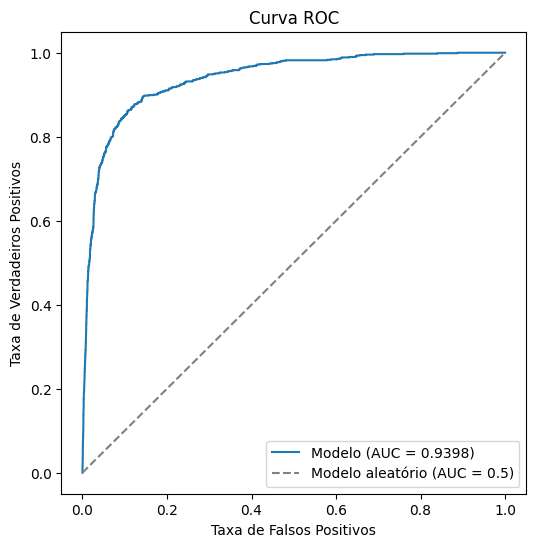

In [ ]:
# Visualização do gráfico

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(validacao['TARGET'], probabilidades_validacao)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'Modelo (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Modelo aleatório (AUC = 0.5)')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC')
plt.legend()
plt.show()

# **6.1) Probabilidade de cada cobrança ser paga (no teste)**

In [ ]:
# Validação por Brier Score se as probabilidade encontradas foi boa

In [ ]:
# Erro muito baixo!

from sklearn.metrics import brier_score_loss

brier = brier_score_loss(validacao['TARGET'], probabilidades_validacao)
print("Brier Score:", brier)

Brier Score: 0.034754428656654256


In [ ]:
# Verificando (visualmente) a probabilidade prevista no teste

validacao['PROBABILIDADE_PREVISTA'] = probabilidades_validacao

validacao[['ID_CLIENTE', 'SAFRA_REF', 'TARGET', 'PROBABILIDADE_PREVISTA']].head(10)

/tmp/ipykernel_12494/2119562166.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  validacao['PROBABILIDADE_PREVISTA'] = probabilidades_validacao


,ID_CLIENTE,SAFRA_REF,TARGET,PROBABILIDADE_PREVISTA
202,8784237149961904,2021-01,0,0.009231
203,8784237149961904,2021-01,0,0.005763
204,8784237149961904,2021-01,0,0.004988
205,8784237149961904,2021-01,0,0.004988
206,8784237149961904,2021-01,0,0.004988
207,8784237149961904,2021-01,0,0.004988
208,8784237149961904,2021-01,0,0.004488
209,8784237149961904,2021-01,0,0.004988
210,8784237149961904,2021-02,0,0.004187
211,8784237149961904,2021-02,0,0.004187


# **7.0) Validação no teste**

# **7.1) Subindo e tratando a base 'teste'**

In [ ]:
# Conversão de datas


test['DATA_EMISSAO_DOCUMENTO'] = pd.to_datetime(test['DATA_EMISSAO_DOCUMENTO'])
test['DATA_VENCIMENTO'] = pd.to_datetime(test['DATA_VENCIMENTO'])

test.dtypes

,0
ID_CLIENTE,int64
SAFRA_REF,object
DATA_EMISSAO_DOCUMENTO,datetime64[ns]
DATA_VENCIMENTO,datetime64[ns]
VALOR_A_PAGAR,float64
TAXA,float64


In [ ]:
# Já convertendo DATA_CADASTRO para data

cad['DATA_CADASTRO'] = pd.to_datetime(cad['DATA_CADASTRO'])

In [ ]:
# Merge de cad e info

test = test.merge(cad, on='ID_CLIENTE', how='left')
test = test.merge(info, on=['ID_CLIENTE', 'SAFRA_REF'], how='left')

test.shape

(12275, 15)

In [ ]:
# Panorama dos nulos na base

# 38 sem DATA_CADASTRO?

test.isnull().sum()

,0
ID_CLIENTE,0
SAFRA_REF,0
DATA_EMISSAO_DOCUMENTO,0
DATA_VENCIMENTO,0
VALOR_A_PAGAR,131
TAXA,0
DATA_CADASTRO,38
DDD,1377
FLAG_PF,12228
SEGMENTO_INDUSTRIAL,254


In [ ]:
# Encontrado o número de nulos - significa que são clientes SEM cadastro

clientes_em_cad = test['ID_CLIENTE'].isin(cad['ID_CLIENTE']).sum()
total_linhas = test.shape[0]

print("Clientes de test que existem em cad:", clientes_em_cad)
print("Total de linhas em test:", total_linhas)
print("Diferença (clientes sem cadastro):", total_linhas - clientes_em_cad)

Clientes de test que existem em cad: 12237
Total de linhas em test: 12275
Diferença (clientes sem cadastro): 38


In [ ]:
# Removendo nulos por 'FALTANTE' em categóricas

colunas_categoricas_teste = ['DDD', 'SEGMENTO_INDUSTRIAL', 'DOMINIO_EMAIL', 'PORTE', 'CEP_2_DIG']

test[colunas_categoricas_teste] = test[colunas_categoricas_teste].fillna('FALTANTE')

test[colunas_categoricas_teste].isnull().sum()

,0
DDD,0
SEGMENTO_INDUSTRIAL,0
DOMINIO_EMAIL,0
PORTE,0
CEP_2_DIG,0


In [ ]:
# As medianas do TREINO (no passado) foram utilizados para preencher nulos


colunas_numericas_teste = ['VALOR_A_PAGAR', 'RENDA_MES_ANTERIOR', 'NO_FUNCIONARIOS']

for col in colunas_numericas_teste:
    mediana_treino = treino[col].median()
    test[col] = test[col].fillna(mediana_treino)

test[colunas_numericas_teste].isnull().sum()

,0
VALOR_A_PAGAR,0
RENDA_MES_ANTERIOR,0
NO_FUNCIONARIOS,0


In [ ]:
# Tratando o FLAG_PF como diz o case

test['FLAG_PF_BIN'] = (test['FLAG_PF'] == 'X').astype(int)
test = test.drop(columns=['FLAG_PF'])

test['FLAG_PF_BIN'].value_counts()

,count
FLAG_PF_BIN,
0,12228
1,47


In [ ]:
# Calculo do Tempo do cadastro em dias

test['TEMPO_CADASTRO_DIAS'] = (test['DATA_EMISSAO_DOCUMENTO'] - test['DATA_CADASTRO']).dt.days
test['TEMPO_CADASTRO_DIAS'] = test['TEMPO_CADASTRO_DIAS'].clip(lower=0)

# Contornar

test['TEMPO_CADASTRO_DIAS'].describe()

# Mesmo número de clientes - não há dados faltantes aqui - Os 38 'NaN' ficaram de fora

# Não há valor negativo

,TEMPO_CADASTRO_DIAS
count,12237.000000
mean,3882.549645
std,2361.607063
min,12.000000
25%,2066.000000
50%,3811.000000
75%,5442.000000
max,7773.000000


In [ ]:
# Mesma função usada no treino para as três novas colunas

def calcular_historico(linha):
    if linha['ID_CLIENTE'] not in historico_por_cliente:
      # Caso o ID do cliente não esteja em dev (já verificado que há 38 nessa situação)
        return pd.Series([np.nan, np.nan, np.nan])

    hist_cliente = historico_por_cliente[linha['ID_CLIENTE']]
    hist_anterior = hist_cliente[hist_cliente['DATA_VENCIMENTO'] < linha['DATA_VENCIMENTO']]

    if len(hist_anterior) == 0:
        return pd.Series([np.nan, np.nan, np.nan])

    return pd.Series([
        hist_anterior['TARGET'].mean(),
        hist_anterior['ATRASO_DIAS'].mean(),
        hist_anterior['VALOR_A_PAGAR'].mean()
    ])

In [ ]:
# Cálculo das novas colunas com base em valores apeans passados, sem futuro (sem vazamento)

test[['PCT_ATRASO_ANTERIOR', 'ATRASO_MEDIO_ANTERIOR', 'VALOR_MEDIO_ANTERIOR']] = test.apply(calcular_historico, axis=1)

test[['ID_CLIENTE', 'DATA_VENCIMENTO', 'PCT_ATRASO_ANTERIOR', 'ATRASO_MEDIO_ANTERIOR', 'VALOR_MEDIO_ANTERIOR']].head(10)

,ID_CLIENTE,DATA_VENCIMENTO,PCT_ATRASO_ANTERIOR,ATRASO_MEDIO_ANTERIOR,VALOR_MEDIO_ANTERIOR
0,5058298901476893676,2021-08-04,0.000000,0.055556,11697.995185
1,274692171162531764,2021-08-23,0.026087,0.321739,34995.052261
2,274692171162531764,2021-08-25,0.026087,0.321739,34995.052261
3,274692171162531764,2021-08-30,0.026087,0.321739,34995.052261
4,465309249432033993,2021-07-30,0.000000,-0.122302,19896.275180
5,465309249432033993,2021-08-03,0.000000,-0.122302,19896.275180
6,465309249432033993,2021-08-09,0.000000,-0.122302,19896.275180
7,465309249432033993,2021-08-09,0.000000,-0.122302,19896.275180
8,5883155883105348987,2021-07-22,0.054054,0.905405,25726.935135
9,5883155883105348987,2021-07-26,0.054054,0.905405,25726.935135


In [ ]:
# Calculando prazo de dias

test['PRAZO_DIAS'] = (test['DATA_VENCIMENTO'] - test['DATA_EMISSAO_DOCUMENTO']).dt.days

In [ ]:
# Função para contar quantas vezes o cliente apareceu antes de tal cobrança específica - em dev

def contar_historico(linha):
    if linha['ID_CLIENTE'] not in historico_por_cliente:
        return 0
    hist_cliente = historico_por_cliente[linha['ID_CLIENTE']]
    hist_anterior = hist_cliente[hist_cliente['DATA_VENCIMENTO'] < linha['DATA_VENCIMENTO']]
    return len(hist_anterior)

test['N_COBRANCAS_ANTERIORES'] = test.apply(contar_historico, axis=1)

In [ ]:
# Verificação se há alguma coluna faltando

# Não há!

# Test pronto!!!

colunas_numericas = ['VALOR_A_PAGAR', 'TAXA', 'PRAZO_DIAS', 'RENDA_MES_ANTERIOR', 'NO_FUNCIONARIOS',
                      'FLAG_PF_BIN', 'TEMPO_CADASTRO_DIAS', 'N_COBRANCAS_ANTERIORES',
                      'PCT_ATRASO_ANTERIOR', 'ATRASO_MEDIO_ANTERIOR', 'VALOR_MEDIO_ANTERIOR']
colunas_categoricas = ['DDD', 'SEGMENTO_INDUSTRIAL', 'DOMINIO_EMAIL', 'PORTE', 'CEP_2_DIG']

faltando = [c for c in colunas_numericas + colunas_categoricas if c not in test.columns]
print("Faltando em test:", faltando)

Faltando em test: []


# **7.2) Treinamento do modelo Final**

In [ ]:
# Treinamento de toda a base - Modelo final

from sklearn.ensemble import HistGradientBoostingClassifier

modelo_final = HistGradientBoostingClassifier(categorical_features='from_dtype', random_state=42)
modelo_final.fit(dev[features], dev['TARGET'])


HistGradientBoostingClassifier(random_state=42)

In [ ]:
# Probabilidade de inadiplência de CADA cobrança - um cliente pode ter várias probabilidades

probabilidades_teste = modelo_final.predict_proba(test[features])[:, 1]

probabilidades_teste[:10]

array([0.00581585, 0.01720403, 0.01919952, 0.01919952, 0.0079082 ,
       0.0079082 , 0.0079082 , 0.0079082 , 0.02843086, 0.02649886])

# **8.0) Previsões**

In [ ]:
# Resposta - Entrega Prncipal

submissao = test[['ID_CLIENTE', 'SAFRA_REF']].copy()
submissao['PROBABILIDADE_INADIPLENCIA'] = probabilidades_teste

submissao.to_csv('submissao_case.csv', index=False)

print("Linhas salvas:", submissao.shape[0])
print("Linhas esperadas (test):", test.shape[0])
submissao.head(10)

Linhas salvas: 12275
Linhas esperadas (test): 12275


,ID_CLIENTE,SAFRA_REF,PROBABILIDADE_INADIPLENCIA
0,5058298901476893676,2021-07,0.005816
1,274692171162531764,2021-07,0.017204
2,274692171162531764,2021-07,0.019200
3,274692171162531764,2021-07,0.019200
4,465309249432033993,2021-07,0.007908
5,465309249432033993,2021-07,0.007908
6,465309249432033993,2021-07,0.007908
7,465309249432033993,2021-07,0.007908
8,5883155883105348987,2021-07,0.028431
9,5883155883105348987,2021-07,0.026499


In [ ]:
# Conferindo se realmente não há valor acima de 1.00 ou valor negativo

submissao['PROBABILIDADE_INADIPLENCIA'].describe()

,PROBABILIDADE_INADIPLENCIA
count,12275.000000
mean,0.048243
std,0.133382
min,0.000273
25%,0.002654
50%,0.006245
75%,0.019402
max,0.956599


In [ ]:
# Verificando se a distribuição faz sentido

percentis = [i / 100 for i in range(0, 101, 5)]

submissao['PROBABILIDADE_INADIPLENCIA'].quantile(percentis)

,PROBABILIDADE_INADIPLENCIA
0.00,0.000273
0.05,0.001115
0.10,0.001508
0.15,0.001874
0.20,0.002204
0.25,0.002654
0.30,0.003191
0.35,0.003813
0.40,0.004590
0.45,0.005333


# **9.0) Versões utilizadas**

In [ ]:
import pandas as pd
import numpy as np
import sklearn

print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)

pandas: 2.2.2
numpy: 2.0.2
scikit-learn: 1.6.1


In [ ]:
import matplotlib
print("matplotlib:", matplotlib.__version__)

matplotlib: 3.10.0


In [ ]:
import sys
print(sys.version)

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [ ]:
with open('requirements.txt', 'w') as f:
    f.write("pandas==2.2.2\n")
    f.write("numpy==2.0.2\n")
    f.write("scikit-learn==1.6.1\n")
    f.write("matplotlib==3.10.0\n")

print("Arquivo requirements.txt criado")

Arquivo requirements.txt criado
